In [1]:
# Block 1: Clone repo và cài đặt thư viện
!git clone -b experiment https://github.com/TrieuKhac-dev/Toxic-Comment-Classification.git
%cd Toxic-Comment-Classification

!pip install -q underthesea wordcloud matplotlib seaborn pandas emoji stopwordsiso nltk scikit-learn

Cloning into 'Toxic-Comment-Classification'...
remote: Enumerating objects: 145, done.
remote: Counting objects: 100% (145/145), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 145 (delta 60), reused 117 (delta 40), pack-reused 0 (from 0)
Receiving objects: 100% (145/145), 56.64 KiB | 2.18 MiB/s, done.
Resolving deltas: 100% (60/60), done.
/content/Toxic-Comment-Classification
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.5 MB/s eta 0:00:00


In [2]:
# Block 2: Import
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter

warnings.filterwarnings("ignore")

# Thêm đường dẫn để import src và config
sys.path.append(os.path.abspath("."))

from src.dataset.loader import download_from_drive, read_csv_with_columns

from config.dataset_config import default_dataset_config
from config.cleaning_config import default_cleaning_config
from config.preprocessing_config import default_preprocessing_config
from config.validation_config import default_validation_config
from config.path_config import default_path_config

from src.dataset.cleaning import (
    remove_special_chars,
    remove_duplicate_comments,
    remove_null_or_empty,
    remove_non_text_comments,
)
from src.dataset.validation import (
    check_null,
    check_empty_or_no_letter,
    check_duplicates,
    check_column_names,
)
# Feature engineering (chỉ thêm đặc trưng số, không preprocessing)
from src.dataset.feature_enginering import (
    add_length_features,
    add_punctuation_emoji_features,
    add_tokens_column,
    add_ttr_column,
)
# EDA (vẽ biểu đồ, phân tích, preprocessing cho EDA)
from src.dataset.eda import (
    plot_label_distribution,
    plot_length_distribution,
    plot_length_boxplot_by_label,
    detect_outliers_isolation_forest,
    preprocess_text_for_eda,
    plot_ttr_boxplot_by_label,
    compare_pos_tags,
    get_top_tokens_by_document_frequency,
    plot_wordcloud,
    get_top_ngrams,
    get_top_ngrams_by_label,
    get_ratio_features,
)
from src.dataset.preprocessing import normalize_text
from src.pipeline.preprocessing_pipeline import get_stopwords_from_config

print("✅ Import thành công!")

✅ Import thành công!


In [3]:
# Block 3: Mount Drive và tạo config dataset
download_from_drive(
    source=default_path_config.drive_raw_dataset_path,
    dest=default_path_config.raw_dataset_path,
)

# Dùng config mặc định, chỉ override description vì khác default
dataset_config = default_dataset_config.override(
    description="Train test dataset for toxic comment classification",
)

# Các config còn lại dùng giá trị mặc định, không cần override
cleaning_config = default_cleaning_config
preprocess_config = default_preprocessing_config
validation_config = default_validation_config

DATA_PATH = default_path_config.raw_dataset_path
print(f"Đường dẫn file: {DATA_PATH}")

Mounted at /content/drive
✅ Đã mount Google Drive vào '/content/drive'
Đã copy file '/content/drive/MyDrive/CommentClassificationDataset/raw_dataset.csv' -> '/content/Toxic-Comment-Classification/dataset/raw/raw_dataset.csv'
Đường dẫn file: /content/Toxic-Comment-Classification/dataset/raw/raw_dataset.csv


In [4]:
# Block 4: Đọc dữ liệu và kiểm tra tên cột
df = read_csv_with_columns(
    data_path=DATA_PATH,
    comment_col=dataset_config.comment_col,
    label_col=dataset_config.label_col,
)

Đã đọc dữ liệu: 6352 dòng, 2 cột
Tất cả các cột yêu cầu đều tồn tại.
   - Cột comment: 'comment'
   - Cột label  : 'is_toxic'


In [5]:
# Block 5: Data Validation
print("\n" + "=" * 50)
print("DATA VALIDATION")
print("=" * 50)

# 1. Null
null_report = check_null(df)
print("\n1. NULL/NaN:")
print(null_report["null_counts"])
print(f"   Tổng null: {null_report['total_null']} ({null_report['null_ratio']:.2%})")

# 2. Empty và no-letter
empty_report = check_empty_or_no_letter(
    df, col=dataset_config.comment_col, check_empty=True, check_no_letter=True
)
print("\n2. Bình luận rỗng hoặc không chữ:")
print(
    f"   - Rỗng (sau trim): {empty_report.get('empty_count', 0)} ({empty_report.get('empty_ratio', 0):.2%})"
)
print(
    f"   - Không chứa chữ cái: {empty_report.get('no_letter_count', 0)} ({empty_report.get('no_letter_ratio', 0):.2%})"
)

# 3. Duplicate
dup_report = check_duplicates(
    df, comment_col=dataset_config.comment_col, label_col=dataset_config.label_col
)
print("\n3. Bình luận trùng lặp:")
print(
    f"   - Tổng số dòng trùng: {dup_report['total_duplicated_rows']} ({dup_report['total_duplicated_rows_ratio']:.2%})"
)
print(
    f"   - Số comment trùng khác nhãn: {dup_report['mixed_label_comments_count']} ({dup_report['mixed_label_ratio']:.2%})"
)
print("   - Số dòng trùng theo lớp:")
for cls, cnt in dup_report["duplicated_rows_by_class"].items():
    print(
        f"       Lớp {cls}: {cnt} ({dup_report['duplicated_rows_ratio_by_class'][cls]:.2%})"
    )

print("\n✅ Data validation hoàn tất.")


DATA VALIDATION

1. NULL/NaN:
comment     0
is_toxic    0
dtype: int64
   Tổng null: 0 (0.00%)

2. Bình luận rỗng hoặc không chữ:
   - Rỗng (sau trim): 0 (0.00%)
   - Không chứa chữ cái: 12 (0.19%)

3. Bình luận trùng lặp:
   - Tổng số dòng trùng: 864 (13.60%)
   - Số comment trùng khác nhãn: 2 (0.60%)
   - Số dòng trùng theo lớp:
       Lớp 1: 845 (13.30%)
       Lớp 0: 19 (0.30%)

✅ Data validation hoàn tất.



PHÂN PHỐI NHÃN
Lớp 1: 3668 (57.75%)
Lớp 0: 2684 (42.25%)


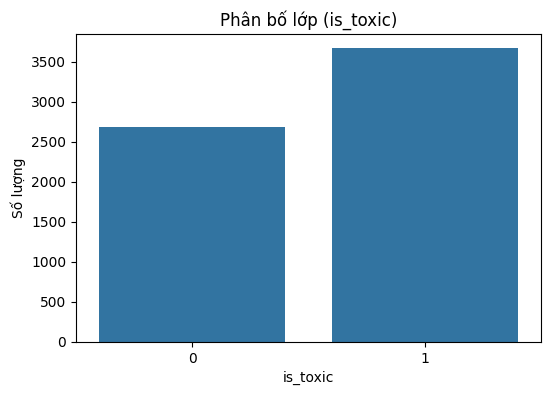

In [6]:
# Block 6: Phân phối nhãn
print("\n" + "=" * 50)
print("PHÂN PHỐI NHÃN")
print("=" * 50)
label_counts = df[dataset_config.label_col].value_counts()
for label, count in label_counts.items():
    print(f"Lớp {label}: {count} ({count / len(df) * 100:.2f}%)")

fig_label = plot_label_distribution(df, label_col=dataset_config.label_col)
plt.show()


===== THỐNG KÊ ĐỘ DÀI (toàn bộ) =====
Số ký tự:
count    6352.000000
mean       58.860989
std        58.846684
min         1.000000
25%        23.000000
50%        41.000000
75%        73.000000
max       707.000000
Name: char_len, dtype: float64

Số từ (token):
count    6352.000000
mean       12.979691
std        12.999584
min         1.000000
25%         5.000000
50%         9.000000
75%        16.000000
max       176.000000
Name: word_len, dtype: float64


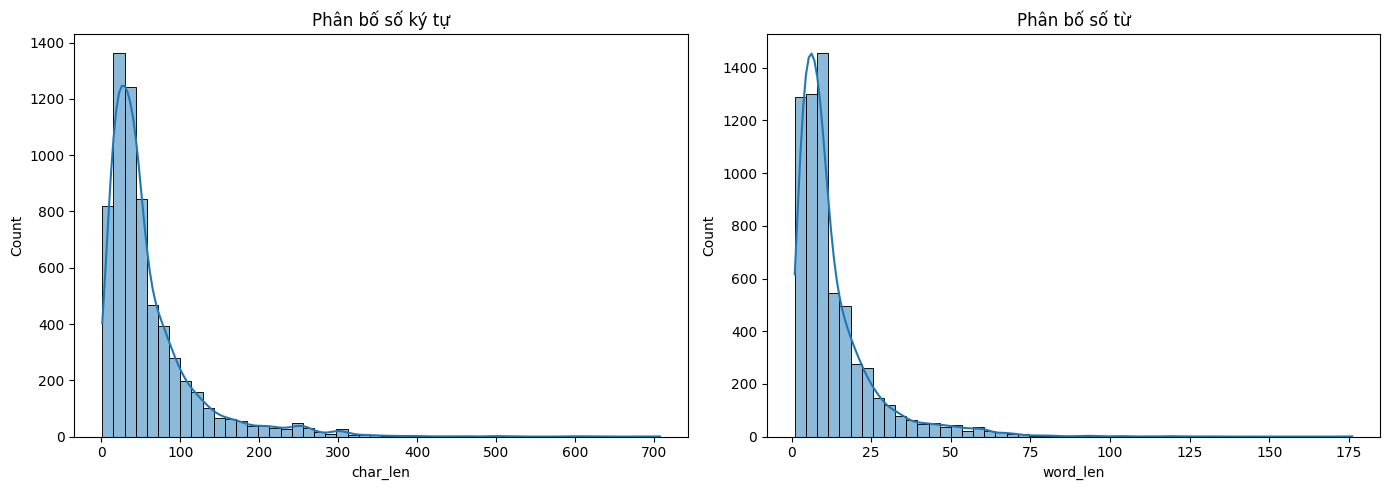


===== THỐNG KÊ ĐỘ DÀI THEO LỚP =====
         char_len                                                       \
            count       mean        std  min   25%   50%    75%    max   
is_toxic                                                                 
0          2684.0  59.245902  59.543122  1.0  23.0  39.0  73.00  607.0   
1          3668.0  58.579335  58.338344  2.0  23.0  42.0  71.25  707.0   

         word_len                                                    
            count       mean        std  min  25%  50%   75%    max  
is_toxic                                                             
0          2684.0  12.805514  12.977984  1.0  5.0  8.0  16.0  113.0  
1          3668.0  13.107143  13.015659  1.0  5.0  9.0  16.0  176.0  


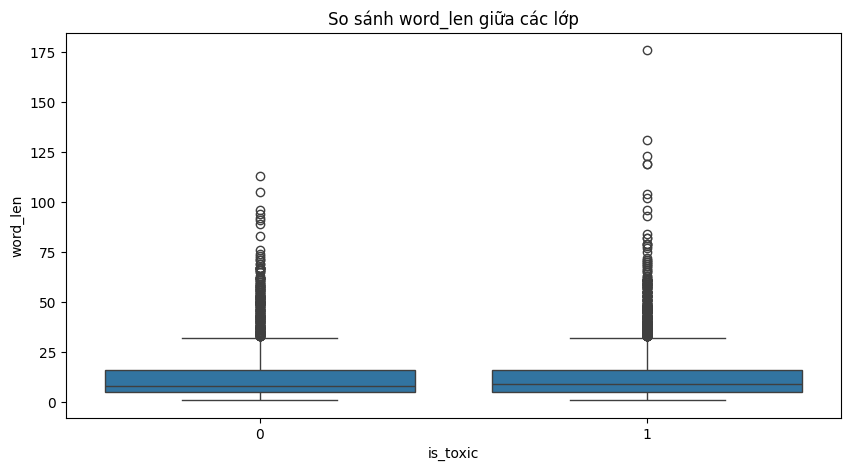

In [7]:
# Block 7: Độ dài bình luận
df = add_length_features(df, comment_col=dataset_config.comment_col)

print("\n===== THỐNG KÊ ĐỘ DÀI (toàn bộ) =====")
print("Số ký tự:")
print(df["char_len"].describe())
print("\nSố từ (token):")
print(df["word_len"].describe())

# Vẽ phân bố
fig_len_dist = plot_length_distribution(df)
plt.show()

# Thống kê theo lớp
print("\n===== THỐNG KÊ ĐỘ DÀI THEO LỚP =====")
print(df.groupby(dataset_config.label_col)[["char_len", "word_len"]].describe())

fig_box = plot_length_boxplot_by_label(
    df, label_col=dataset_config.label_col, length_col="word_len"
)
plt.show()

In [8]:
# Block 8: Thêm đặc trưng punctuation, emoji
df = add_punctuation_emoji_features(df, comment_col=dataset_config.comment_col)
print("Đã thêm các cột: num_exclamation, num_question, num_upper, num_emoji")

Đã thêm các cột: num_exclamation, num_question, num_upper, num_emoji


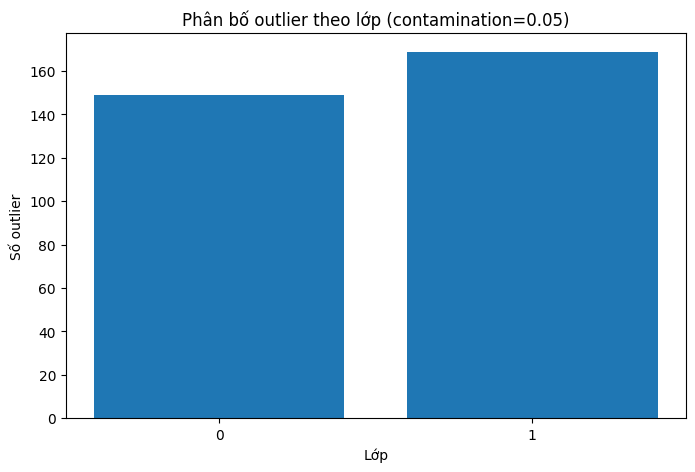

===== PHÁT HIỆN OUTLIER =====
Số outlier: 318
Phân bố outlier theo lớp:
is_toxic
1    169
0    149
Name: count, dtype: int64
Tỷ lệ outlier lớp 0: 5.55%
Tỷ lệ outlier lớp 1: 4.61%


In [9]:
# Block 9: Outlier detection
outlier_mask, fig_out = detect_outliers_isolation_forest(
    df,
    feature_cols=cleaning_config.outlier_feature_cols,
    contamination=cleaning_config.outlier_contamination,
    random_state=cleaning_config.outlier_random_state,
    label_col=dataset_config.label_col,
)
plt.show()
print("===== PHÁT HIỆN OUTLIER =====")
print(f"Số outlier: {outlier_mask.sum()}")
outlier_class_counts = df.loc[outlier_mask, dataset_config.label_col].value_counts()
print("Phân bố outlier theo lớp:")
print(outlier_class_counts)
if len(outlier_class_counts) > 0:
    pct0 = (
        outlier_class_counts.get(0, 0)
        / len(df[df[dataset_config.label_col] == 0])
        * 100
    )
    pct1 = (
        outlier_class_counts.get(1, 0)
        / len(df[df[dataset_config.label_col] == 1])
        * 100
    )
    print(f"Tỷ lệ outlier lớp 0: {pct0:.2f}%")
    print(f"Tỷ lệ outlier lớp 1: {pct1:.2f}%")

Đã tải 645 stopwords tiếng Việt (từ preprocessing).
Đã tạo cột 'tokens' (đã loại stopwords và dấu câu).

===== THỐNG KÊ TYPE-TOKEN RATIO (TTR) THEO LỚP =====
           count      mean       std  min       25%  50%  75%  max
is_toxic                                                          
0         2684.0  0.941531  0.127438  0.0  0.923077  1.0  1.0  1.0
1         3668.0  0.953336  0.092165  0.0  0.928571  1.0  1.0  1.0


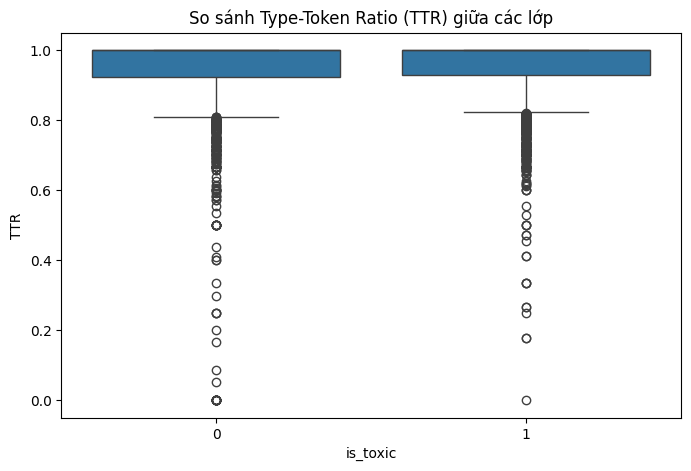

In [10]:
# Block 10: Token và TTR
stopwords = get_stopwords_from_config(preprocess_config)
print(f"Đã tải {len(stopwords)} stopwords tiếng Việt (từ preprocessing).")

keep_punct = cleaning_config.keep_punctuation
# Bước 1: Preprocess text (norm, remove_special_chars, filter_stopwords) — từ eda.py
df["tokens"] = df[dataset_config.comment_col].apply(
    lambda x: preprocess_text_for_eda(x, stopwords=stopwords, keep_punctuation=keep_punct)
)
print("Đã tạo cột 'tokens' (đã loại stopwords và dấu câu).")

# Bước 2: Thêm đặc trưng TTR — từ feature_enginering.py
df = add_ttr_column(df)
print("\n===== THỐNG KÊ TYPE-TOKEN RATIO (TTR) THEO LỚP =====")
print(df.groupby(dataset_config.label_col)["ttr"].describe())

fig_ttr = plot_ttr_boxplot_by_label(df, label_col=dataset_config.label_col)
plt.show()

===== TOP 10 LOẠI TỪ XUẤT HIỆN NHIỀU HƠN Ở LỚP VI PHẠM =====
              Loại từ  Lớp 0  Lớp 1  Chênh lệch
13             Đại từ     57    200         143
4   Danh từ chỉ người     32    114          82
5             Động từ   1077   1149          72
6       Danh từ chung   1482   1544          62
3            Lượng từ     23     49          26
9              Trợ từ     45     53           8
16                 Ny      0      2           2
15    Từ chuyên ngành    382    383           1
14            Thán từ      1      2           1
8             Liên từ      2      3           1

===== TOP 10 LOẠI TỪ XUẤT HIỆN NHIỀU HƠN Ở LỚP BÌNH THƯỜNG =====
            Loại từ  Lớp 0  Lớp 1  Chênh lệch
10          Tính từ    353    235        -118
1   Từ chỉ số lượng    349    298         -51
17           Phó từ     79     55         -24
11            Số từ     33     30          -3
7       Từ cảm thán      4      1          -3
12    Từ nước ngoài      6      4          -2
0    Ký tự đặc biệt    

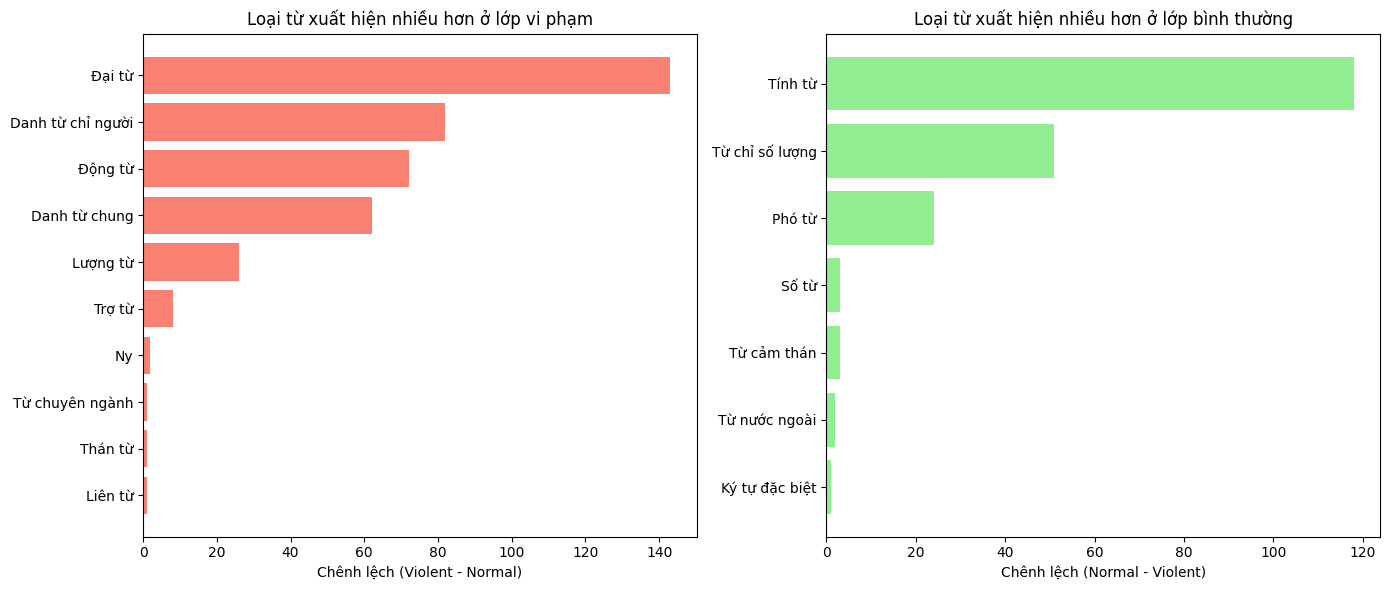

In [11]:
# Block 11: POS tag comparison
pos_df, pos_fig = compare_pos_tags(
    df, label_col=dataset_config.label_col, sample_size=500
)
print("===== TOP 10 LOẠI TỪ XUẤT HIỆN NHIỀU HƠN Ở LỚP VI PHẠM =====")
print(
    pos_df[pos_df["Chênh lệch"] > 0].sort_values("Chênh lệch", ascending=False).head(10)
)
print("\n===== TOP 10 LOẠI TỪ XUẤT HIỆN NHIỀU HƠN Ở LỚP BÌNH THƯỜNG =====")
print(
    pos_df[pos_df["Chênh lệch"] < 0].sort_values("Chênh lệch", ascending=True).head(10)
)
plt.show()

===== TOP 100 TỪ XUẤT HIỆN NHIỀU NHẤT (document frequency) =====
      Cột 1       Cột 2           Cột 3         Cột 4           Cột 5
   , (1263)  giao (189)   xin lỗi (125)     thêm (92)        kia (78)
   . (1156)   lắm (188)        lũ (119)        v (91)        giờ (77)
  mày (511)     ! (185)       mèo (119)      mặt (91)       chịu (77)
thằng (486)   bắt (180)        xe (115)      địt (91)         ad (77)
   ko (343)  nhìn (172)       xin (115)       cc (88)       chơi (77)
  chó (333)   mua (172)       đấy (114)     nghe (88)       hiểu (75)
   mẹ (329)  thật (170)         3 (111)     toàn (87)         hả (75)
  ngu (318)  shop (161)       tốt (110)       bố (87)          5 (74)
  mấy (303)   xem (160) trọng tài (109)       đm (87)        tụi (74)
    m (268)     t (155)         r (109)      mất (87)     xã hội (74)
    ? (246) nhanh (153)       lồn (106)       bỏ (87)       đừng (73)
  tao (236) thích (149)       ... (106)      lấy (87)        coi (73)
 hàng (234)  tiền (145)  

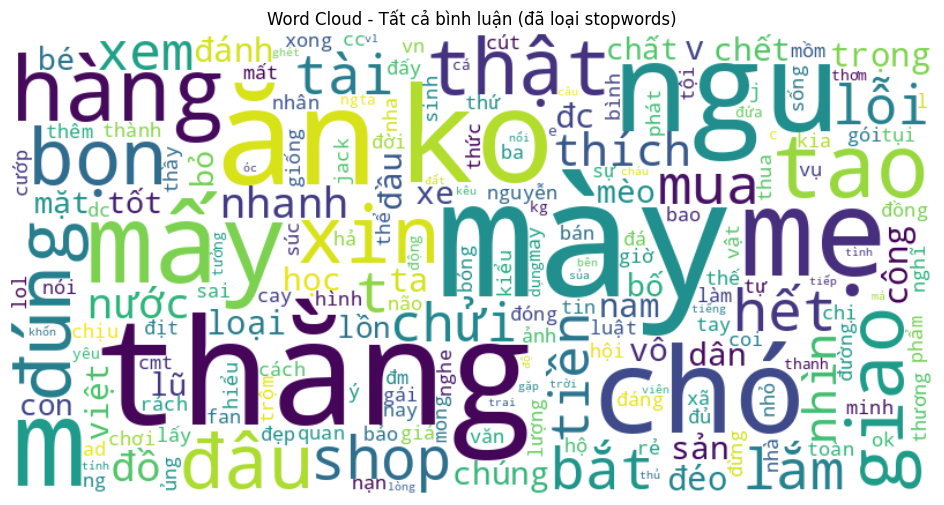

In [12]:
# Block 12: Top từ và WordCloud
top_tokens = get_top_tokens_by_document_frequency(df, top_n=100)
print("===== TOP 100 TỪ XUẤT HIỆN NHIỀU NHẤT (document frequency) =====")
num_cols = 5
items_per_col = 20
rows = []
for i in range(items_per_col):
    row = []
    for j in range(num_cols):
        idx = i + j * items_per_col
        if idx < len(top_tokens):
            token, count = top_tokens[idx]
            row.append(f"{token} ({count})")
        else:
            row.append("")
    rows.append(row)
df_top = pd.DataFrame(rows, columns=[f"Cột {i + 1}" for i in range(num_cols)])
print(df_top.to_string(index=False))

fig_wc = plot_wordcloud(df)
plt.show()

In [13]:
# Block 13: N-grams
for n in [2, 3]:
    print(f"\n===== TOP 100 {n}-GRAM PHỔ BIẾN NHẤT (TOÀN BỘ) =====")
    top_ngrams = get_top_ngrams(df, n=n, top_n=100)
    num_cols = 5
    items_per_col = 20
    columns = []
    for col in range(num_cols):
        start = col * items_per_col
        end = start + items_per_col
        col_items = top_ngrams[start:end]
        columns.append([f"{' '.join(ngram)} ({count})" for ngram, count in col_items])
    max_len = max(len(col) for col in columns)
    for col in columns:
        col.extend([""] * (max_len - len(col)))
    df_ngram = pd.DataFrame(columns=[f"Cột {i + 1}" for i in range(num_cols)])
    for i in range(max_len):
        row = [col[i] for col in columns]
        df_ngram.loc[i] = row
    print(df_ngram.to_string(index=False))

# N-grams theo lớp
ngrams_by_label = get_top_ngrams_by_label(
    df, label_col=dataset_config.label_col, n=2, top_n=100
)
for label, ngram_list in ngrams_by_label.items():
    print(f"\n===== TOP 100 2-GRAM CHO LỚP {label} =====")
    columns = []
    for col in range(num_cols):
        start = col * items_per_col
        end = start + items_per_col
        col_items = ngram_list[start:end]
        columns.append([f"{' '.join(ngram)} ({count})" for ngram, count in col_items])
    max_len = max(len(col) for col in columns)
    for col in columns:
        col.extend([""] * (max_len - len(col)))
    df_ngram_label = pd.DataFrame(columns=[f"Cột {i + 1}" for i in range(num_cols)])
    for i in range(max_len):
        row = [col[i] for col in columns]
        df_ngram_label.loc[i] = row
    print(df_ngram_label.to_string(index=False))


===== TOP 100 2-GRAM PHỔ BIẾN NHẤT (TOÀN BỘ) =====
          Cột 1            Cột 2                  Cột 3                    Cột 4               Cột 5
      ! ! (133)       . mua (30)             tốt . (22)                , ăn (19)       nhìn mặt (17)
giao hàng (127)    thích ăn (30)         mèo thích (22)             chúng m (19)        chết mẹ (17)
      ? ? (126)     tao mày (28)             , mèo (22)             , thằng (19)            . m (17)
   mẹ mày (101)     nhanh . (28)             , tao (21)              thơm , (19)       trẻ trâu (17)
       , , (76)      . giao (28)             mày . (21)            mày biến (19)         mấy bé (17)
 mấy thằng (70)     mấy đứa (27)            . đúng (21)             đúng đồ (19)       lắm thật (17)
hàng nhanh (69)        , ko (27) đóng gói cẩn thận (21) chất lượng sản phẩm (19)  https tiki.vn (17)
 thằng ngu (53)       . mày (27)            . shop (21)                 . t (18)      đồ ngu si (17)
       , k (52)       lắm . (26)       

In [14]:
# Block 14: Từ đặc trưng theo tỷ lệ tần suất
violent_words, normal_words = get_ratio_features(df, label_col=dataset_config.label_col)


def display_ratio_table(words, title):
    print(f"\n{title}")
    num_cols = 5
    items_per_col = 20
    columns = []
    for col in range(num_cols):
        start = col * items_per_col
        end = start + items_per_col
        col_items = words[start:end]
        formatted = [f"{w} ({score:.2f})" for w, score in col_items]
        columns.append(formatted)
    max_len = max(len(col) for col in columns)
    for col in columns:
        col.extend([""] * (max_len - len(col)))
    df_show = pd.DataFrame(columns=[f"Cột {i + 1}" for i in range(num_cols)])
    for i in range(max_len):
        row = [col[i] for col in columns]
        df_show.loc[i] = row
    print(df_show.to_string(index=False))


display_ratio_table(
    violent_words, "===== 100 TỪ ĐẶC TRƯNG CHO LỚP VI PHẠM (tỷ lệ cao) ====="
)
display_ratio_table(
    normal_words, "===== 100 TỪ ĐẶC TRƯNG CHO LỚP BÌNH THƯỜNG (tỷ lệ thấp) ====="
)

print("\n✅ EDA hoàn tất.")


===== 100 TỪ ĐẶC TRƯNG CHO LỚP VI PHẠM (tỷ lệ cao) =====
           Cột 1             Cột 2              Cột 3              Cột 4               Cột 5
     địt (96.00)       mày (24.36)  não phẳng (17.00)        tao (12.95)          mỏ (11.00)
     cút (65.00)        đĩ (24.00)  chúng mày (17.00)      thằng (12.40)          di (11.00)
khốn nạn (55.00)       lòn (24.00)    bực mày (17.00)    trẻ con (12.00)      cặn bã (11.00)
     ngu (49.29)  rác rưởi (23.00)        dái (16.00)    súc vật (12.00)          dơ (10.50)
      dm (43.00)      ruồi (23.00)     chế độ (16.00) thiểu năng (12.00)        chết (10.31)
     cặc (40.00)       cức (23.00)       sory (16.00)       loài (12.00)  tinh trùng (10.00)
     cứt (39.00)        đụ (22.00)        dlv (16.00)       trâu (12.00)        rách (10.00)
     đít (38.00)        cc (22.00) khuyết tật (16.00)        tàu (12.00)         dog (10.00)
     đéo (36.25)       đần (22.00)       ranh (15.00)        đmm (12.00)      ông bà (10.00)
      lũ (32